# Introduction to Cross-Validation

Cross-validation is a fundamental technique in machine learning that helps us evaluate model performance more reliably than simple train-test splits. This notebook explores various cross-validation methods and their practical implementation.

## 1. Import Required Libraries

Let's start by importing the essential libraries we'll need for implementing cross-validation.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning and cross-validation
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, LeaveOneOut, TimeSeriesSplit
from sklearn.model_selection import learning_curve

# Some common models to use with cross-validation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# For datasets
from sklearn.datasets import load_iris, load_breast_cancer, make_classification

# For metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Configure visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set(font_scale=1.2)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Understanding Cross-Validation Concept

Cross-validation is a statistical method used to evaluate machine learning models by training several models on subsets of the available input data and evaluating them on the complementary subset of the data.

### Why Use Cross-Validation?

1. **Better use of data**: Every observation is used for both training and validation
2. **More reliable performance estimates**: Multiple evaluations reduce the variance in performance estimation
3. **Helps detect overfitting**: If a model performs well on training data but poorly on validation data across folds

Let's start by demonstrating why a simple train-test split may be limiting:

Training accuracy: 0.9619
Testing accuracy: 1.0000

Test accuracies with different random splits:
Min: 0.9111, Max: 1.0000, Mean: 0.9667, Std: 0.0248


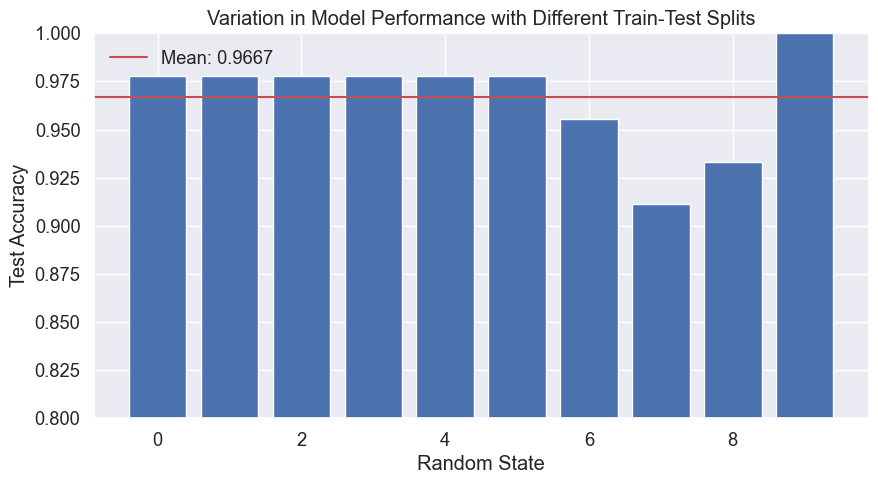

In [2]:
# Load a dataset for our examples
iris = load_iris()
X = iris.data
y = iris.target

# Simple train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a model
model = LogisticRegression(max_iter=200)

# Train and evaluate the model
model.fit(X_train, y_train)
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Training accuracy: {train_score:.4f}")
print(f"Testing accuracy: {test_score:.4f}")

# Let's see what happens if we use different random states for the split
results = []
for random_state in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    test_score = model.score(X_test, y_test)
    results.append(test_score)

print("\nTest accuracies with different random splits:")
print(f"Min: {min(results):.4f}, Max: {max(results):.4f}, Mean: {np.mean(results):.4f}, Std: {np.std(results):.4f}")

# Visualize the variation
plt.figure(figsize=(10, 5))
plt.bar(range(10), results)
plt.axhline(y=np.mean(results), color='r', linestyle='-', label=f'Mean: {np.mean(results):.4f}')
plt.xlabel('Random State')
plt.ylabel('Test Accuracy')
plt.title('Variation in Model Performance with Different Train-Test Splits')
plt.ylim(0.8, 1.0)
plt.legend()
plt.show()

The variation in test accuracy demonstrates why a single train-test split can be unreliable for model evaluation. Cross-validation addresses this by using multiple train-test splits and averaging the results.

## 3. K-Fold Cross-Validation Implementation

K-fold cross-validation divides the dataset into k equal-sized folds. The model is trained on k-1 folds and validated on the remaining fold. This process is repeated k times, with each fold used exactly once as the validation data.

Let's implement k-fold cross-validation using scikit-learn:

Individual fold scores: [1.         1.         0.93333333 0.96666667 0.96666667]
Mean accuracy: 0.9733
Standard deviation: 0.0249


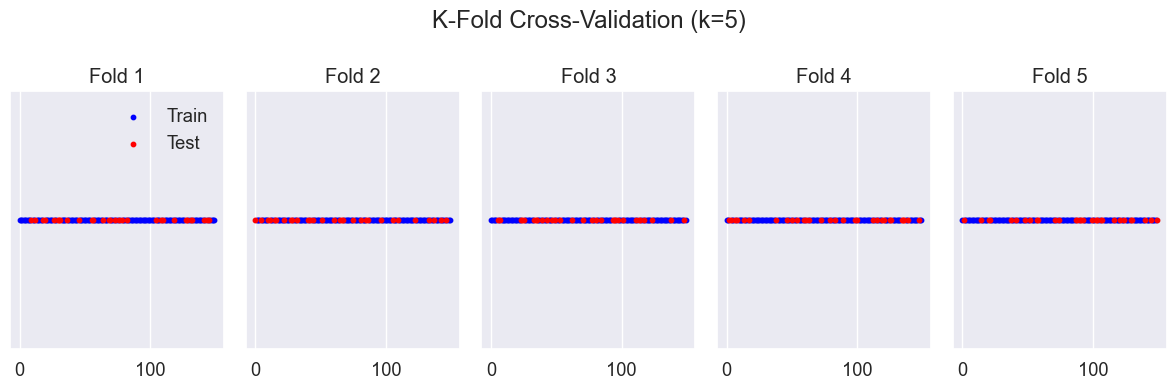


Cross-validation results with multiple metrics:
                          mean       std
fit_time              0.024039  0.003298
score_time            0.007007  0.002268
test_accuracy         0.973333  0.027889
test_precision_macro  0.975983  0.027338
test_recall_macro     0.974444  0.027666
test_f1_macro         0.973213  0.030384


In [3]:
# Create a k-fold cross-validation object
k = 5  # Number of folds
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Initialize a model
model = LogisticRegression(max_iter=200)

# Perform k-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

# Print individual fold scores and average
print(f"Individual fold scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

# Let's visualize the cross-validation procedure
plt.figure(figsize=(12, 4))
for i, (train_index, test_index) in enumerate(kf.split(X)):
    plt.subplot(1, k, i+1)
    plt.scatter(range(len(X)), [0]*len(X), c='lightgray', s=10)
    plt.scatter(train_index, [0]*len(train_index), c='blue', s=10, label='Train')
    plt.scatter(test_index, [0]*len(test_index), c='red', s=10, label='Test')
    plt.title(f"Fold {i+1}")
    plt.yticks([])
    if i == 0:
        plt.legend()
plt.suptitle("K-Fold Cross-Validation (k=5)")
plt.tight_layout()
plt.show()

# Compare multiple metrics using cross_validate
metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_results = cross_validate(model, X, y, cv=kf, scoring=metrics)

# Print results in a table
results_df = pd.DataFrame(cv_results)
print("\nCross-validation results with multiple metrics:")
print(results_df.describe().loc[['mean', 'std']].T)

## 4. Stratified K-Fold Cross-Validation

When dealing with classification problems, especially with imbalanced classes, it's important that each fold maintains the same class distribution as the original dataset. This is where stratified k-fold comes in.

Let's compare standard k-fold with stratified k-fold:

Class distribution in the dataset:
Class 0: 897 samples (89.7%)
Class 1: 103 samples (10.3%)


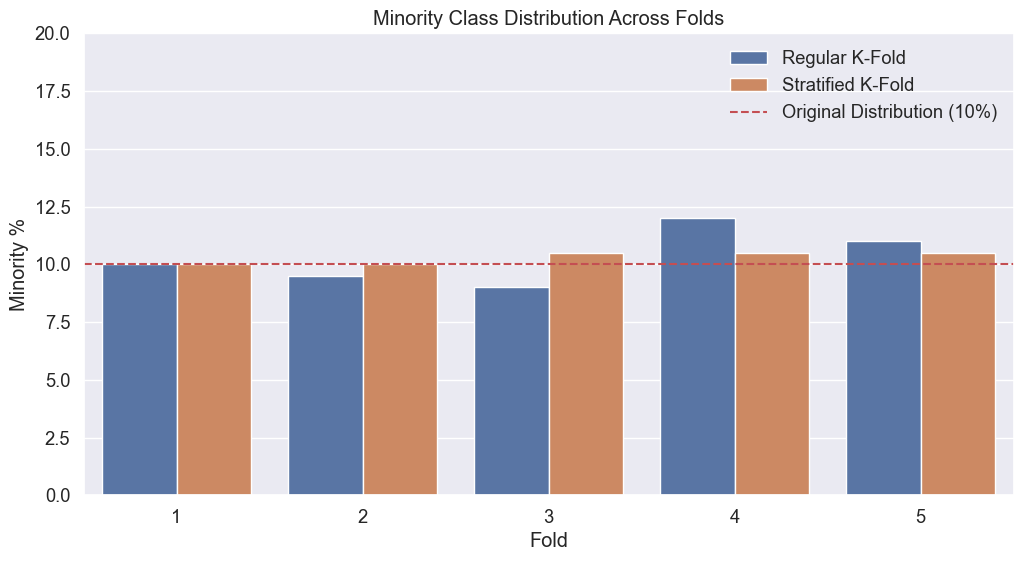


F1 scores - Regular K-Fold: [0.36363636 0.6875     0.62857143 0.63414634 0.7027027 ]
F1 scores - Stratified K-Fold: [0.42424242 0.57142857 0.63157895 0.60606061 0.54545455]
Regular K-Fold mean F1: 0.6033 (±0.1233)
Stratified K-Fold mean F1: 0.5558 (±0.0720)


In [4]:
# Create an imbalanced dataset for demonstration
X_imb, y_imb = make_classification(n_samples=1000, n_classes=2, weights=[0.9, 0.1], 
                                   random_state=42)

# Print class distribution
print("Class distribution in the dataset:")
unique, counts = np.unique(y_imb, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} samples ({count/len(y_imb)*100:.1f}%)")

# Define both KFold and StratifiedKFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Function to check class distribution in each fold
def check_fold_distribution(cv_splitter, X, y):
    fold_stats = []
    for i, (_, test_index) in enumerate(cv_splitter.split(X, y)):
        y_test = y[test_index]
        minority_pct = np.mean(y_test == 1) * 100
        fold_stats.append((i+1, len(y_test), minority_pct))
    return fold_stats

# Compare fold distributions
regular_stats = check_fold_distribution(kf, X_imb, y_imb)
stratified_stats = check_fold_distribution(skf, X_imb, y_imb)

# Create a dataframe to display the results
regular_df = pd.DataFrame(regular_stats, columns=['Fold', 'Size', 'Minority %'])
regular_df['Method'] = 'Regular K-Fold'
stratified_df = pd.DataFrame(stratified_stats, columns=['Fold', 'Size', 'Minority %'])
stratified_df['Method'] = 'Stratified K-Fold'
comparison_df = pd.concat([regular_df, stratified_df])

# Plot the comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Fold', y='Minority %', hue='Method', data=comparison_df)
plt.axhline(y=10, color='r', linestyle='--', label='Original Distribution (10%)')
plt.ylim(0, 20)
plt.title('Minority Class Distribution Across Folds')
plt.legend()
plt.show()

# Compare model performance
model = LogisticRegression(max_iter=200)
reg_scores = cross_val_score(model, X_imb, y_imb, cv=kf, scoring='f1')
strat_scores = cross_val_score(model, X_imb, y_imb, cv=skf, scoring='f1')

print("\nF1 scores - Regular K-Fold:", reg_scores)
print("F1 scores - Stratified K-Fold:", strat_scores)
print(f"Regular K-Fold mean F1: {reg_scores.mean():.4f} (±{reg_scores.std():.4f})")
print(f"Stratified K-Fold mean F1: {strat_scores.mean():.4f} (±{strat_scores.std():.4f})")

As demonstrated above, stratified k-fold maintains the same class distribution across all folds, which typically results in more reliable performance metrics for imbalanced classification problems.

## 5. Leave-One-Out Cross-Validation

Leave-One-Out Cross-Validation (LOOCV) is a special case of k-fold cross-validation where k equals the number of samples in the dataset. This means each sample is used exactly once as the validation data.

LOOCV is computationally expensive but can be useful for small datasets where we want to maximize the training data.

In [11]:
# # Create a small dataset for LOOCV demonstration
# small_iris = load_iris()
# X_small = small_iris.data[:30]  # Using only 30 samples to keep computation manageable
# y_small = small_iris.target[:30]

# # Create LOOCV object
# loo = LeaveOneOut()

# # Calculate the number of splits
# n_splits = loo.get_n_splits(X_small)
# print(f"Number of splits in LOOCV: {n_splits}")

# # Perform LOOCV
# model = LogisticRegression(max_iter=200)
# loo_scores = cross_val_score(model, X_small, y_small, cv=loo, scoring='accuracy')

# print(f"LOOCV Mean Accuracy: {loo_scores.mean():.4f}")
# print(f"LOOCV Standard Deviation: {loo_scores.std():.4f}")

# # Compare LOOCV with k-fold CV
# k_values = [3, 5, 10, len(X_small)]  # The last one is equivalent to LOOCV
# k_results = []

# for k in k_values[:-1]:  # Exclude LOOCV from this loop
#     kf = KFold(n_splits=k, shuffle=True, random_state=42)
#     scores = cross_val_score(model, X_small, y_small, cv=kf, scoring='accuracy')
#     k_results.append((k, scores.mean(), scores.std()))

# # Add LOOCV results
# k_results.append((k_values[-1], loo_scores.mean(), loo_scores.std()))

# # Create a dataframe for visualization
# k_df = pd.DataFrame(k_results, columns=['k', 'Mean Accuracy', 'Std'])

# # Plot results
# plt.figure(figsize=(10, 6))
# plt.errorbar(k_df['k'], k_df['Mean Accuracy'], yerr=k_df['Std'], marker='o', linestyle='-')
# plt.xlabel('Number of Folds (k)')
# plt.ylabel('Accuracy')
# plt.title('Cross-Validation Performance vs. Number of Folds')
# plt.xscale('log')
# plt.xticks(k_df['k'], [str(k) for k in k_df['k']])
# plt.grid(True)
# plt.show()

# # Measure execution time
# import time
# cv_times = []

# for k in k_values[:-1]:  # Regular k-fold CV
#     kf = KFold(n_splits=k, shuffle=True, random_state=42)
#     start_time = time.time()
#     cross_val_score(model, X_small, y_small, cv=kf)
#     end_time = time.time()
#     cv_times.append((k, end_time - start_time))

# # LOOCV time
# start_time = time.time()
# cross_val_score(model, X_small, y_small, cv=loo)
# end_time = time.time()
# cv_times.append((k_values[-1], end_time - start_time))

# # Plot execution times
# time_df = pd.DataFrame(cv_times, columns=['k', 'Execution Time (s)'])
# plt.figure(figsize=(10, 6))
# plt.bar(range(len(time_df)), time_df['Execution Time (s)'])
# plt.xlabel('Cross-Validation Method')
# plt.ylabel('Execution Time (seconds)')
# plt.title('Computational Cost of Different Cross-Validation Methods')
# plt.xticks(range(len(time_df)), [f"{k}-fold" if k < len(X_small) else "LOOCV" for k in time_df['k']])
# plt.show()

```
ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)
```

Class distribution: {np.int64(0): np.int64(10), np.int64(1): np.int64(10), np.int64(2): np.int64(10)}
Number of splits in LOOCV: 30
LOOCV Mean Accuracy: 0.9667
LOOCV Standard Deviation: 0.1795


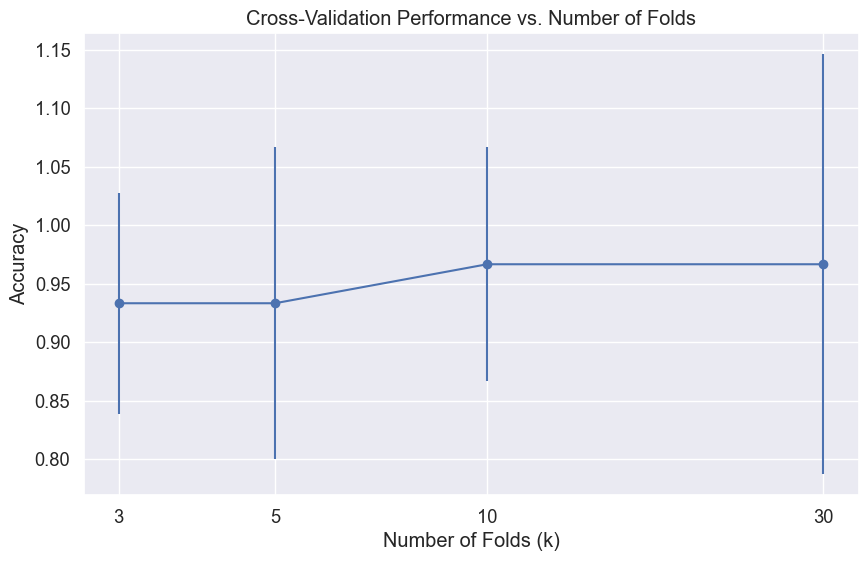

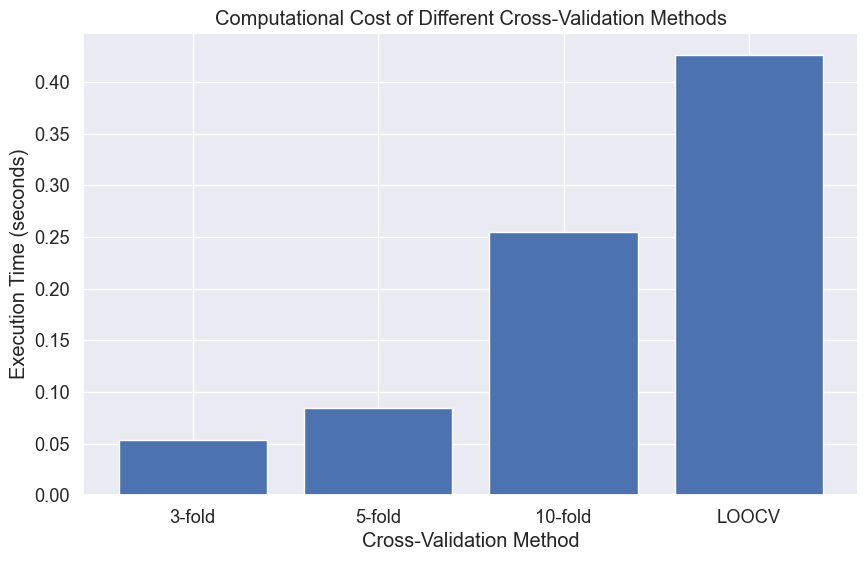

In [10]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score, KFold
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a balanced small dataset for LOOCV demonstration
small_iris = load_iris()
# Get 10 samples from each class to ensure class balance
indices = np.hstack([np.where(small_iris.target == i)[0][:10] for i in range(3)])
X_small = small_iris.data[indices]
y_small = small_iris.target[indices]

# Verify class distribution
unique_classes, class_counts = np.unique(y_small, return_counts=True)
print(f"Class distribution: {dict(zip(unique_classes, class_counts))}")

# Create LOOCV object
loo = LeaveOneOut()

# Calculate the number of splits
n_splits = loo.get_n_splits(X_small)
print(f"Number of splits in LOOCV: {n_splits}")

# Perform LOOCV
model = LogisticRegression(max_iter=200)
loo_scores = cross_val_score(model, X_small, y_small, cv=loo, scoring='accuracy')

print(f"LOOCV Mean Accuracy: {loo_scores.mean():.4f}")
print(f"LOOCV Standard Deviation: {loo_scores.std():.4f}")

# Compare LOOCV with k-fold CV
k_values = [3, 5, 10, len(X_small)]  # The last one is equivalent to LOOCV
k_results = []
for k in k_values[:-1]:  # Exclude LOOCV from this loop
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_small, y_small, cv=kf, scoring='accuracy')
    k_results.append((k, scores.mean(), scores.std()))

# Add LOOCV results
k_results.append((k_values[-1], loo_scores.mean(), loo_scores.std()))

# Create a dataframe for visualization
k_df = pd.DataFrame(k_results, columns=['k', 'Mean Accuracy', 'Std'])

# Plot results
plt.figure(figsize=(10, 6))
plt.errorbar(k_df['k'], k_df['Mean Accuracy'], yerr=k_df['Std'], marker='o', linestyle='-')
plt.xlabel('Number of Folds (k)')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Performance vs. Number of Folds')
plt.xscale('log')
plt.xticks(k_df['k'], [str(k) for k in k_df['k']])
plt.grid(True)
plt.show()

# Measure execution time
import time
cv_times = []
for k in k_values[:-1]:  # Regular k-fold CV
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    start_time = time.time()
    cross_val_score(model, X_small, y_small, cv=kf)
    end_time = time.time()
    cv_times.append((k, end_time - start_time))

# LOOCV time
start_time = time.time()
cross_val_score(model, X_small, y_small, cv=loo)
end_time = time.time()
cv_times.append((k_values[-1], end_time - start_time))

# Plot execution times
time_df = pd.DataFrame(cv_times, columns=['k', 'Execution Time (s)'])
plt.figure(figsize=(10, 6))
plt.bar(range(len(time_df)), time_df['Execution Time (s)'])
plt.xlabel('Cross-Validation Method')
plt.ylabel('Execution Time (seconds)')
plt.title('Computational Cost of Different Cross-Validation Methods')
plt.xticks(range(len(time_df)), [f"{k}-fold" if k < len(X_small) else "LOOCV" for k in time_df['k']])
plt.show()

## 6. Time Series Cross-Validation

Traditional cross-validation assumes that the data points are independent of each other, which is not the case for time series data where there's a temporal dependency. For time series, we need special cross-validation techniques:

1. **Time Series Split**: Training on past data, testing on future data
2. **Expanding Window**: Increasing the training set size as we move forward in time

Let's demonstrate time series cross-validation:

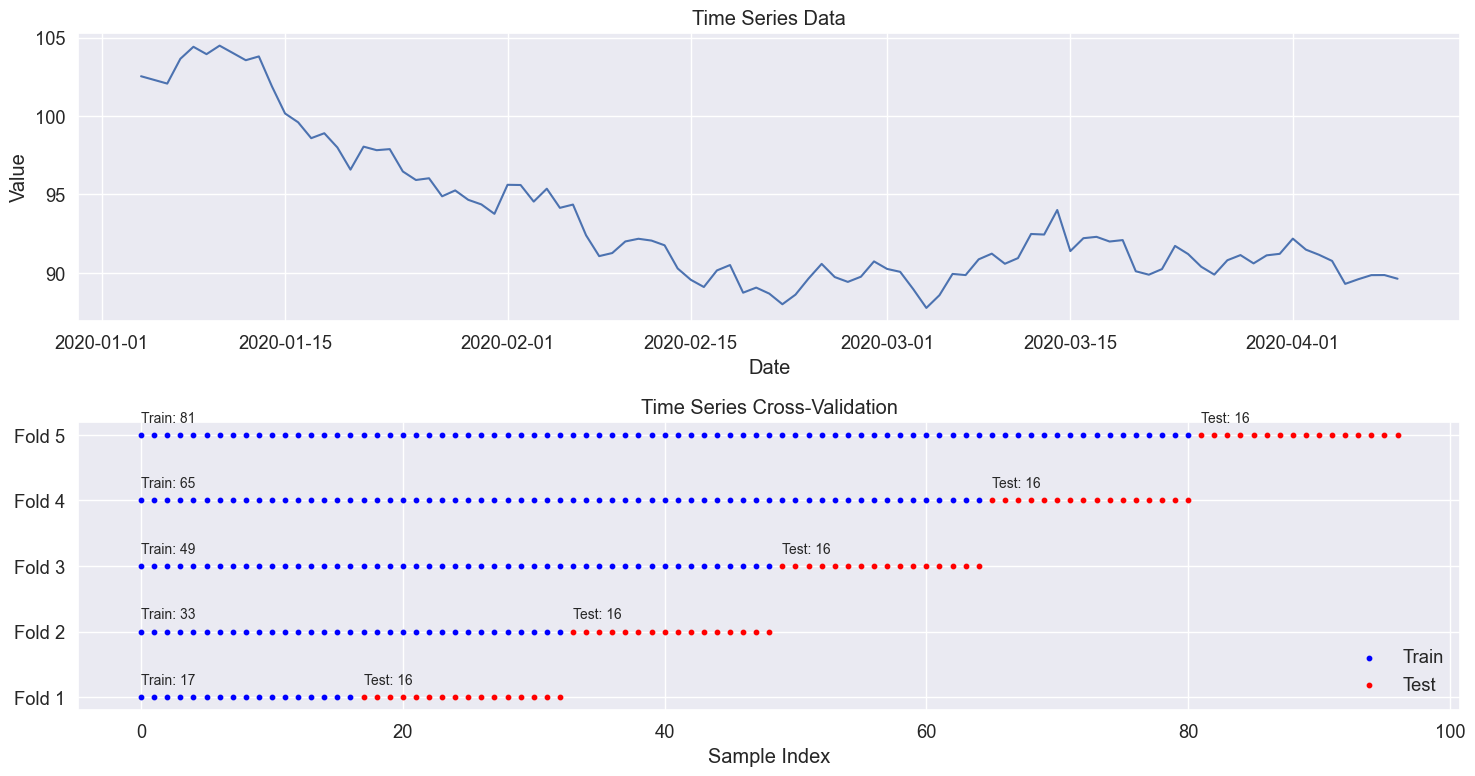

Time Series CV - RMSE scores: [1.0855056  0.89711562 0.89874319 1.13680227 0.6216326 ]
Time Series CV - Mean RMSE: 0.9280
Time Series CV - Standard Deviation: 0.1812

Standard KFold CV - RMSE scores: [0.89031597 0.96607542 1.05854367 0.78438886 0.94830822]
Standard KFold CV - Mean RMSE: 0.9295


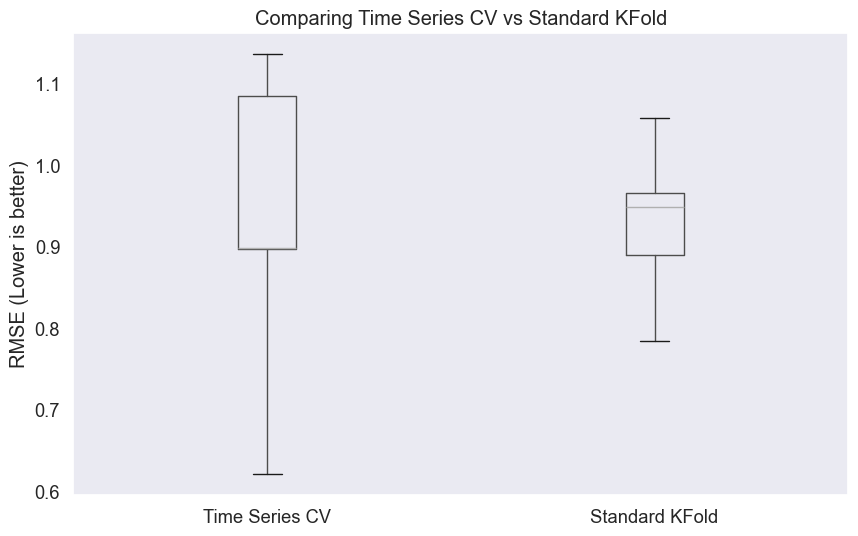

In [12]:
# Generate a synthetic time series dataset
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
values = np.cumsum(np.random.randn(100)) + 100  # Random walk with drift
ts_data = pd.DataFrame({'date': dates, 'value': values})

# Add lag features to use for prediction
ts_data['lag1'] = ts_data['value'].shift(1)
ts_data['lag2'] = ts_data['value'].shift(2)
ts_data['lag3'] = ts_data['value'].shift(3)
ts_data = ts_data.dropna()  # Remove rows with NaN values

X_ts = ts_data[['lag1', 'lag2', 'lag3']].values
y_ts = ts_data['value'].values

# Create TimeSeriesSplit object
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Visualize the time series split
plt.figure(figsize=(15, 8))

# Plot the time series data
plt.subplot(2, 1, 1)
plt.plot(ts_data['date'], ts_data['value'])
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')

# Plot the splits
plt.subplot(2, 1, 2)
for i, (train_index, test_index) in enumerate(tscv.split(X_ts)):
    train_size = len(train_index)
    test_size = len(test_index)
    
    # Calculate x positions for this fold
    fold_start = min(train_index)
    fold_end = max(test_index)
    train_x = np.arange(fold_start, fold_start + train_size)
    test_x = np.arange(fold_start + train_size, fold_start + train_size + test_size)
    
    # Plot train and test for this fold
    plt.scatter(train_x, [i+0.5]*len(train_x), c='blue', s=10, label='Train' if i == 0 else "")
    plt.scatter(test_x, [i+0.5]*len(test_x), c='red', s=10, label='Test' if i == 0 else "")
    
    # Add text labels
    plt.text(fold_start, i+0.7, f"Train: {len(train_index)}", fontsize=10, ha='left')
    plt.text(fold_start + train_size, i+0.7, f"Test: {len(test_index)}", fontsize=10, ha='left')

plt.title('Time Series Cross-Validation')
plt.yticks(np.arange(0.5, n_splits + 0.5), [f'Fold {i+1}' for i in range(n_splits)])
plt.xlabel('Sample Index')
plt.legend()
plt.tight_layout()
plt.show()

# Perform time series cross-validation
from sklearn.linear_model import LinearRegression
model = LinearRegression()
ts_scores = cross_val_score(model, X_ts, y_ts, cv=tscv, scoring='neg_mean_squared_error')

# Convert negative MSE to RMSE for easier interpretation
ts_rmse = np.sqrt(-ts_scores)
print(f"Time Series CV - RMSE scores: {ts_rmse}")
print(f"Time Series CV - Mean RMSE: {ts_rmse.mean():.4f}")
print(f"Time Series CV - Standard Deviation: {ts_rmse.std():.4f}")

# Compare with standard k-fold (which would be incorrect for time series)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = cross_val_score(model, X_ts, y_ts, cv=kf, scoring='neg_mean_squared_error')
kf_rmse = np.sqrt(-kf_scores)

print(f"\nStandard KFold CV - RMSE scores: {kf_rmse}")
print(f"Standard KFold CV - Mean RMSE: {kf_rmse.mean():.4f}")

# Compare the results
result_comparison = pd.DataFrame({
    'Time Series CV': ts_rmse,
    'Standard KFold': kf_rmse
})
plt.figure(figsize=(10, 6))
result_comparison.boxplot()
plt.ylabel('RMSE (Lower is better)')
plt.title('Comparing Time Series CV vs Standard KFold')
plt.grid(False)
plt.show()

Notice that standard k-fold likely gives optimistically biased results for time series data because it allows the model to "peek into the future" during training. Time series cross-validation enforces a temporal separation between training and testing data, providing a more realistic assessment of model performance.

## 7. Cross-Validation with GridSearchCV

One of the most common applications of cross-validation is hyperparameter tuning. GridSearchCV uses cross-validation to find the best hyperparameters for a model by exhaustively testing all parameter combinations.

Let's implement a grid search with cross-validation:

### RUN ON MAC

In [ ]:
# Load a dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

# Define a model and parameter grid
svm = SVC(probability=True)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

# Create the GridSearchCV object with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all available CPU cores
)

# Perform grid search
grid_search.fit(X_train, y_train)

# Print results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy with best model: {test_accuracy:.4f}")

# Visualize the grid search results
results = pd.DataFrame(grid_search.cv_results_)
best_idx = results['rank_test_score'].idxmin()

# Create a pivoted table for visualization
pivot_table = pd.DataFrame()

for kernel in param_grid['kernel']:
    kernel_results = results[results['param_kernel'] == kernel]
    pivot = kernel_results.pivot_table(
        index='param_gamma', 
        columns='param_C', 
        values='mean_test_score'
    )
    pivot = pivot.rename_axis(index=None, columns=None)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu')
    plt.title(f'Grid Search Results - {kernel.upper()} Kernel')
    plt.xlabel('C')
    plt.ylabel('gamma')
    plt.tight_layout()
    plt.show()

# Nested Cross-Validation
# This helps avoid overfitting to the validation set during hyperparameter tuning

def nested_cv(X, y, inner_cv=5, outer_cv=5):
    # Define the parameter grid
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': [0.1, 1, 'scale'],
        'kernel': ['rbf', 'linear']
    }
    
    # Define the inner and outer cross-validation
    inner_cv_obj = StratifiedKFold(n_splits=inner_cv, shuffle=True, random_state=42)
    outer_cv_obj = StratifiedKFold(n_splits=outer_cv, shuffle=True, random_state=42)
    
    # Create the models
    svm = SVC(probability=True)
    grid_search = GridSearchCV(svm, param_grid, cv=inner_cv_obj, scoring='accuracy')
    
    # Nested cross-validation
    outer_scores = []
    best_params = []
    
    for i, (train_idx, test_idx) in enumerate(outer_cv_obj.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Inner CV for hyperparameter tuning
        grid_search.fit(X_train, y_train)
        
        # Save best parameters
        best_params.append(grid_search.best_params_)
        
        # Evaluate on the test set
        best_model = grid_search.best_estimator_
        score = best_model.score(X_test, y_test)
        outer_scores.append(score)
        
        print(f"Outer fold {i+1}: Best parameters = {grid_search.best_params_}, Score = {score:.4f}")
    
    return outer_scores, best_params

# Run nested cross-validation
print("\nPerforming nested cross-validation...")
nested_scores, nested_params = nested_cv(X_cancer, y_cancer)

print(f"\nNested CV mean accuracy: {np.mean(nested_scores):.4f}")
print(f"Nested CV standard deviation: {np.std(nested_scores):.4f}")

# Compare the best parameters chosen in each outer fold
print("\nBest parameters chosen in each outer fold:")
for i, params in enumerate(nested_params):
    print(f"Fold {i+1}: {params}")

## 8. Visualizing Cross-Validation Results

Visualizing the results of cross-validation can provide insights into model performance and stability. Common visualizations include:

1. Distribution of performance across folds
2. Learning curves to diagnose overfitting/underfitting
3. Validation curves to examine the effect of a single hyperparameter

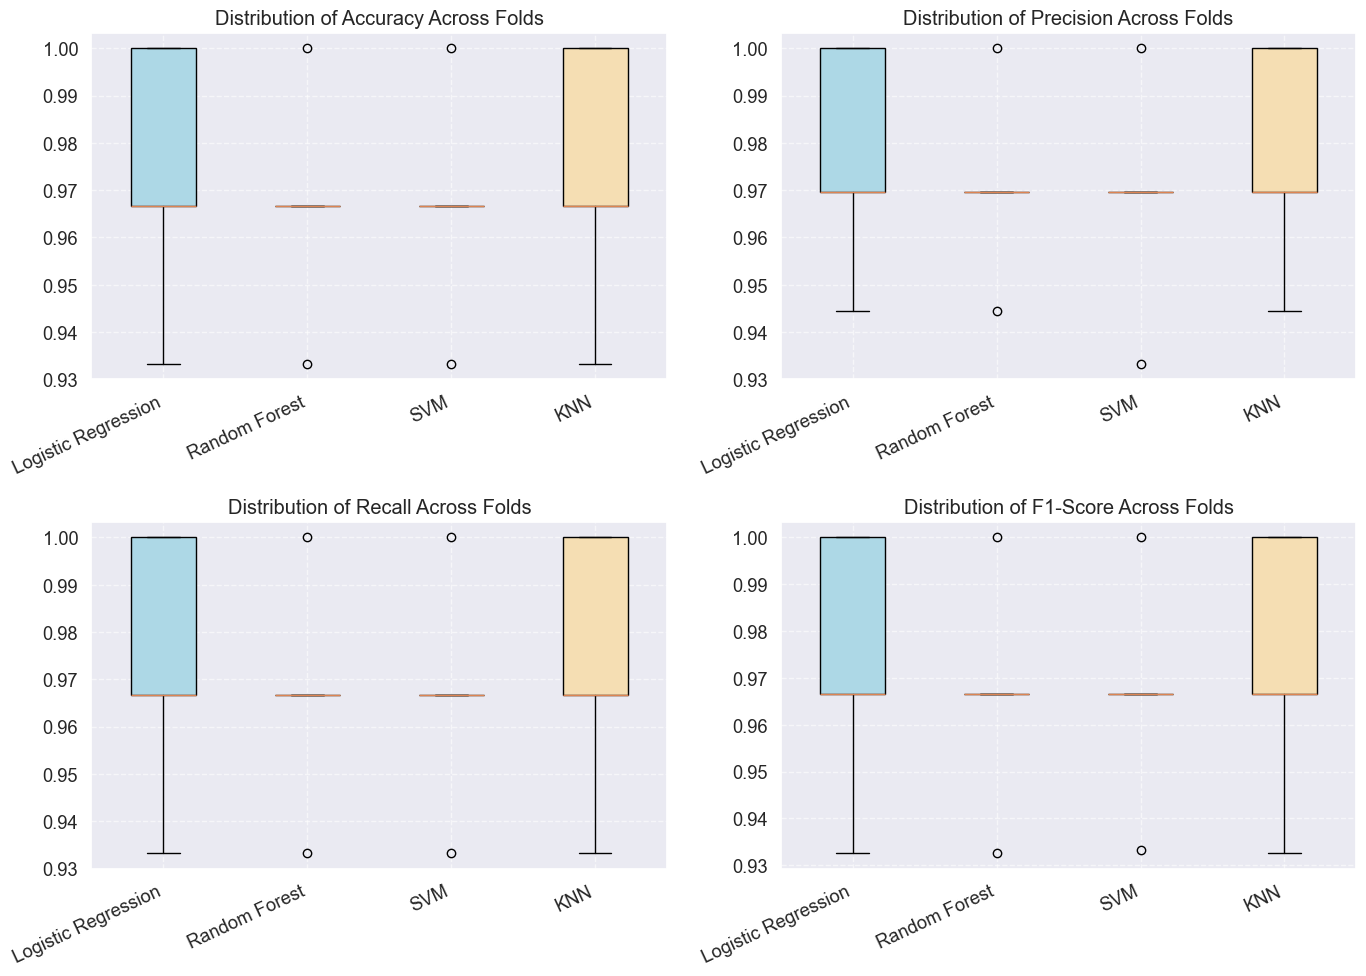

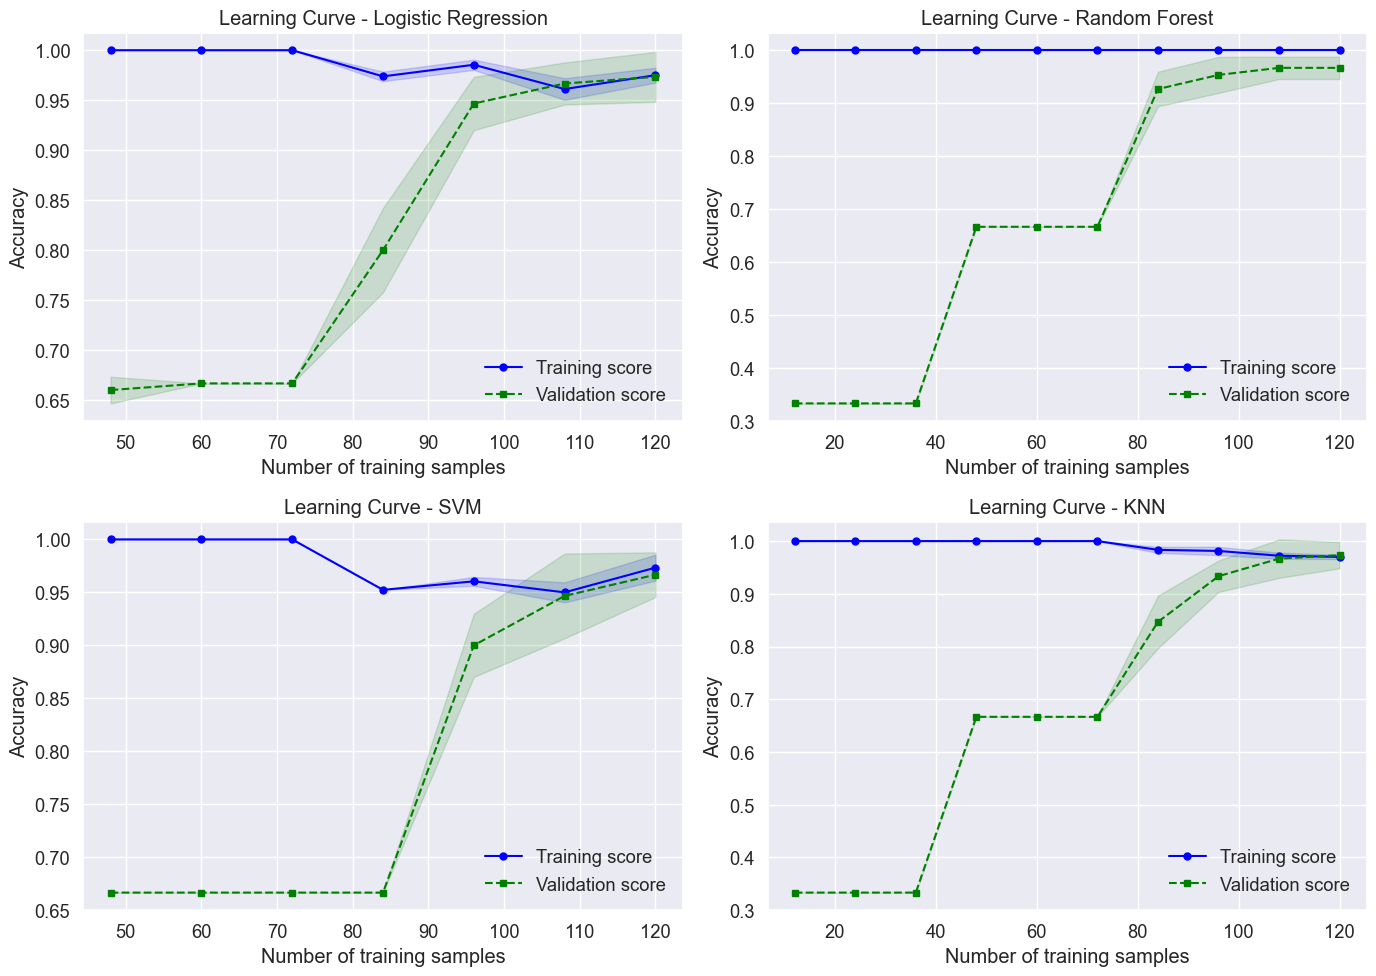

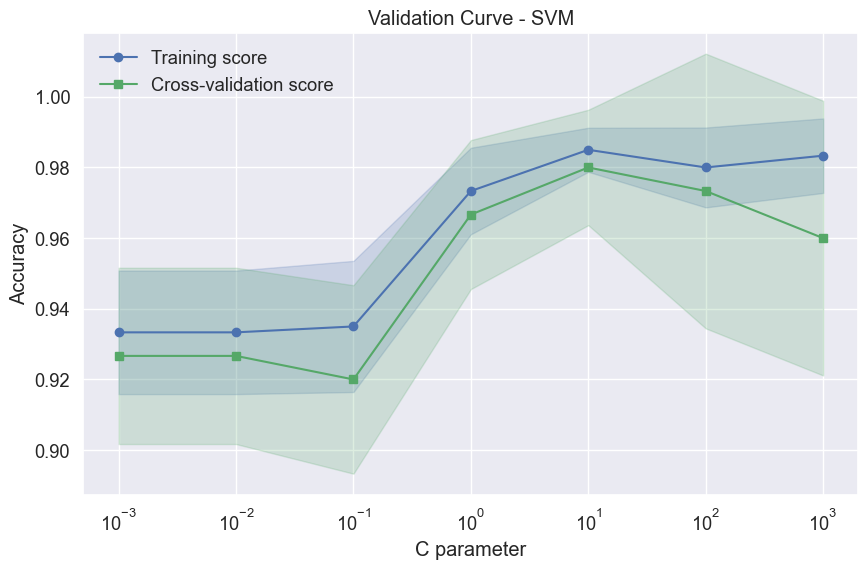

In [14]:
# Function to perform cross-validation and return detailed scores
def get_cv_scores(model, X, y, cv=5):
    cv_results = cross_validate(
        model, 
        X, 
        y, 
        cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        return_train_score=True
    )
    return cv_results

# Get cross-validation scores for multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

# Use iris dataset
X, y = load_iris(return_X_y=True)

# Cross-validation with multiple models
cv_results_dict = {}
for name, model in models.items():
    cv_results_dict[name] = get_cv_scores(model, X, y)

# 1. Visualize performance distribution across folds
plt.figure(figsize=(14, 10))

# Extract metrics
metrics = ['test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    
    # Prepare data for box plot
    data_to_plot = []
    labels = []
    
    for name in models.keys():
        data_to_plot.append(cv_results_dict[name][metric])
        labels.append(name)
    
    # Create box plot
    box = plt.boxplot(data_to_plot, patch_artist=True, labels=labels)
    
    # Add some color
    colors = ['lightblue', 'lightgreen', 'lightpink', 'wheat']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    
    plt.title(f'Distribution of {metric_labels[i]} Across Folds')
    plt.xticks(rotation=25, ha='right')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Learning curves
from sklearn.model_selection import learning_curve

plt.figure(figsize=(14, 10))

for i, (name, model) in enumerate(models.items()):
    plt.subplot(2, 2, i+1)
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    
    plt.plot(train_sizes, test_mean, color='green', marker='s', linestyle='--', markersize=5, label='Validation score')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')
    
    plt.title(f'Learning Curve - {name}')
    plt.xlabel('Number of training samples')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend(loc='lower right')
    
plt.tight_layout()
plt.show()

# 3. Validation curve for a single hyperparameter
from sklearn.model_selection import validation_curve

# Choose SVM and vary C parameter
param_range = np.logspace(-3, 3, 7)
train_scores, test_scores = validation_curve(
    SVC(), X, y, param_name="C", param_range=param_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Validation Curve - SVM")
plt.xlabel("C parameter")
plt.ylabel("Accuracy")
plt.semilogx(param_range, train_mean, 'o-', color="b", label="Training score")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="b")
plt.semilogx(param_range, test_mean, 's-', color="g", label="Cross-validation score")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="g")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## 9. Evaluating Model Performance

In this final section, we'll compare multiple models using cross-validation and analyze the statistical significance of differences in performance to make informed model selection decisions.

In [17]:
# # Let's use the breast cancer dataset for this example
# X, y = load_breast_cancer(return_X_y=True)

# # Define several models to compare
# models = {
#     'Logistic Regression': LogisticRegression(max_iter=1000),
#     'Random Forest': RandomForestClassifier(random_state=42),
#     'SVM (RBF)': SVC(kernel='rbf', probability=True),
#     'SVM (Linear)': SVC(kernel='linear', probability=True),
#     'KNN': KNeighborsClassifier()
# }

# # Set up cross-validation
# cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# # Store results for each model
# all_results = {}

# for name, model in models.items():
#     print(f"Evaluating {name}...")
#     scores = cross_validate(
#         model, X, y, cv=cv,
#         scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc'],
#         return_train_score=True
#     )
    
#     all_results[name] = {
#         'test_accuracy': scores['test_accuracy'],
#         'test_precision': scores['test_precision_macro'],
#         'test_recall': scores['test_recall_macro'],
#         'test_f1': scores['test_f1_macro'],
#         'test_roc_auc': scores['test_roc_auc'],
#         'train_accuracy': scores['train_accuracy']
#     }

# # Create a comparison dataframe for test scores
# comparison_data = []
# for model_name, results in all_results.items():
#     for metric_name, scores in results.items():
#         if metric_name.startswith('test_'):
#             for fold, score in enumerate(scores):
#                 comparison_data.append({
#                     'Model': model_name,
#                     'Metric': metric_name.replace('test_', ''),
#                     'Fold': fold + 1,
#                     'Score': score
#                 })

# comparison_df = pd.DataFrame(comparison_data)

# # Calculate summary statistics
# summary = comparison_df.groupby(['Model', 'Metric'])['Score'].agg(['mean', 'std']).reset_index()
# summary = summary.sort_values(by=['Metric', 'mean'], ascending=[True, False])

# # Print summary table
# print("\nModel Performance Summary:")
# for metric in summary['Metric'].unique():
#     print(f"\n{metric.upper()}")
#     metric_data = summary[summary['Metric'] == metric].sort_values(by='mean', ascending=False)
#     print(metric_data[['Model', 'mean', 'std']].to_string(index=False, 
#                                                          float_format=lambda x: f"{x:.4f}"))

# # Create visualizations for model comparison
# plt.figure(figsize=(15, 10))

# metrics = comparison_df['Metric'].unique()
# for i, metric in enumerate(metrics):
#     plt.subplot(2, 3, i+1)
    
#     metric_data = comparison_df[comparison_df['Metric'] == metric]
#     sns.boxplot(x='Model', y='Score', data=metric_data)
    
#     plt.title(f'{metric.capitalize()} Comparison')
#     plt.xticks(rotation=45, ha='right')
#     plt.tight_layout()

# plt.tight_layout()
# plt.show()

# # Statistical significance testing (paired t-test)
# from scipy import stats

# print("\nStatistical Significance Tests (p-values):")
# for metric in metrics:
#     print(f"\nMetric: {metric}")
    
#     # Create a table for p-values
#     model_names = list(models.keys())
#     p_values = np.zeros((len(model_names), len(model_names)))
    
#     for i, model_1 in enumerate(model_names):
#         for j, model_2 in enumerate(model_names):
#             if i != j:
#                 # Get scores for both models
#                 scores_1 = all_results[model_1][f'test_{metric}']
#                 scores_2 = all_results[model_2][f'test_{metric}']
                
#                 # Perform paired t-test
#                 _, p_value = stats.ttest_rel(scores_1, scores_2)
#                 p_values[i, j] = p_value
    
#     # Create a DataFrame for better visualization
#     p_value_df = pd.DataFrame(p_values, index=model_names, columns=model_names)
    
#     # Highlight significant differences (p < 0.05)
#     def highlight_significant(val):
#         color = 'yellow' if val < 0.05 else ''
#         return f'background-color: {color}'
    
#     # Display styled DataFrame
#     styled_df = p_value_df.style.format("{:.4f}").applymap(highlight_significant)
#     display(styled_df)

# # Final model selection - calculate a combined score
# # Normalize all metrics to 0-1 range and compute a weighted average
# # This is just an example approach - the specific weights should be chosen based on your application needs

# def normalize(scores):
#     min_score = np.min(scores)
#     max_score = np.max(scores)
#     if max_score > min_score:
#         return (scores - min_score) / (max_score - min_score)
#     return np.zeros_like(scores)

# # Define weights for each metric
# weights = {
#     'accuracy': 0.25,
#     'precision': 0.25,
#     'recall': 0.25,
#     'f1': 0.15,
#     'roc_auc': 0.1
# }

# # Calculate combined scores
# combined_scores = {}

# for model_name, results in all_results.items():
#     combined = np.zeros(len(results['test_accuracy']))
    
#     for metric, weight in weights.items():
#         metric_scores = results[f'test_{metric}']
#         # Get all scores across all models for this metric
#         all_metric_scores = np.concatenate([res[f'test_{metric}'] for res in all_results.values()])
#         # Normalize
#         normalized = normalize(metric_scores)
#         combined += weight * normalized
    
#     combined_scores[model_name] = combined

# # Create a DataFrame for combined scores
# combined_df = pd.DataFrame({
#     'Model': np.repeat(list(combined_scores.keys()), [len(scores) for scores in combined_scores.values()]),
#     'Combined Score': np.concatenate(list(combined_scores.values()))
# })

# # Plot combined scores
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='Model', y='Combined Score', data=combined_df)
# plt.title('Combined Model Performance Score')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

# # Print final recommendations
# print("\nFinal Model Recommendations:")
# for model, scores in combined_scores.items():
#     print(f"{model}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")

```
The error you're encountering is related to the `wmic` command that's used by joblib to determine the number of physical cores on Windows. This command has been deprecated in newer Windows versions and Python 3.13.

I've made the following key changes to fix the issue:

1. Added the necessary imports that were missing in the original code
2. Set the environment variable `LOKY_MAX_CPU_COUNT` to bypass the problematic `wmic` call
3. Set `n_jobs=1` in the `cross_validate` function to prevent parallel processing that would trigger the issue

This approach forces joblib to use a single process, which avoids the problematic core counting function altogether. If you want to use parallel processing, the environment variable approach should help joblib determine the CPU count correctly without relying on the `wmic` command.

The rest of the code remains the same, preserving all the model evaluation, visualization, and statistical testing functionality.
```

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating SVM (RBF)...
Evaluating SVM (Linear)...
Evaluating KNN...

Model Performance Summary:

ACCURACY
              Model   mean    std
      Random Forest 0.9561 0.0252
       SVM (Linear) 0.9561 0.0189
Logistic Regression 0.9526 0.0287
                KNN 0.9350 0.0309
          SVM (RBF) 0.9156 0.0386

F1
              Model   mean    std
      Random Forest 0.9526 0.0278
       SVM (Linear) 0.9525 0.0210
Logistic Regression 0.9485 0.0320
                KNN 0.9290 0.0361
          SVM (RBF) 0.9050 0.0457

PRECISION
              Model   mean    std
       SVM (Linear) 0.9578 0.0190
      Random Forest 0.9559 0.0239
Logistic Regression 0.9553 0.0273
                KNN 0.9380 0.0282
          SVM (RBF) 0.9303 0.0329

RECALL
              Model   mean    std
      Random Forest 0.9514 0.0316
       SVM (Linear) 0.9494 0.0235
Logistic Regression 0.9456 0.0365
                KNN 0.9250 0.0409
          SVM (RBF) 0.8931

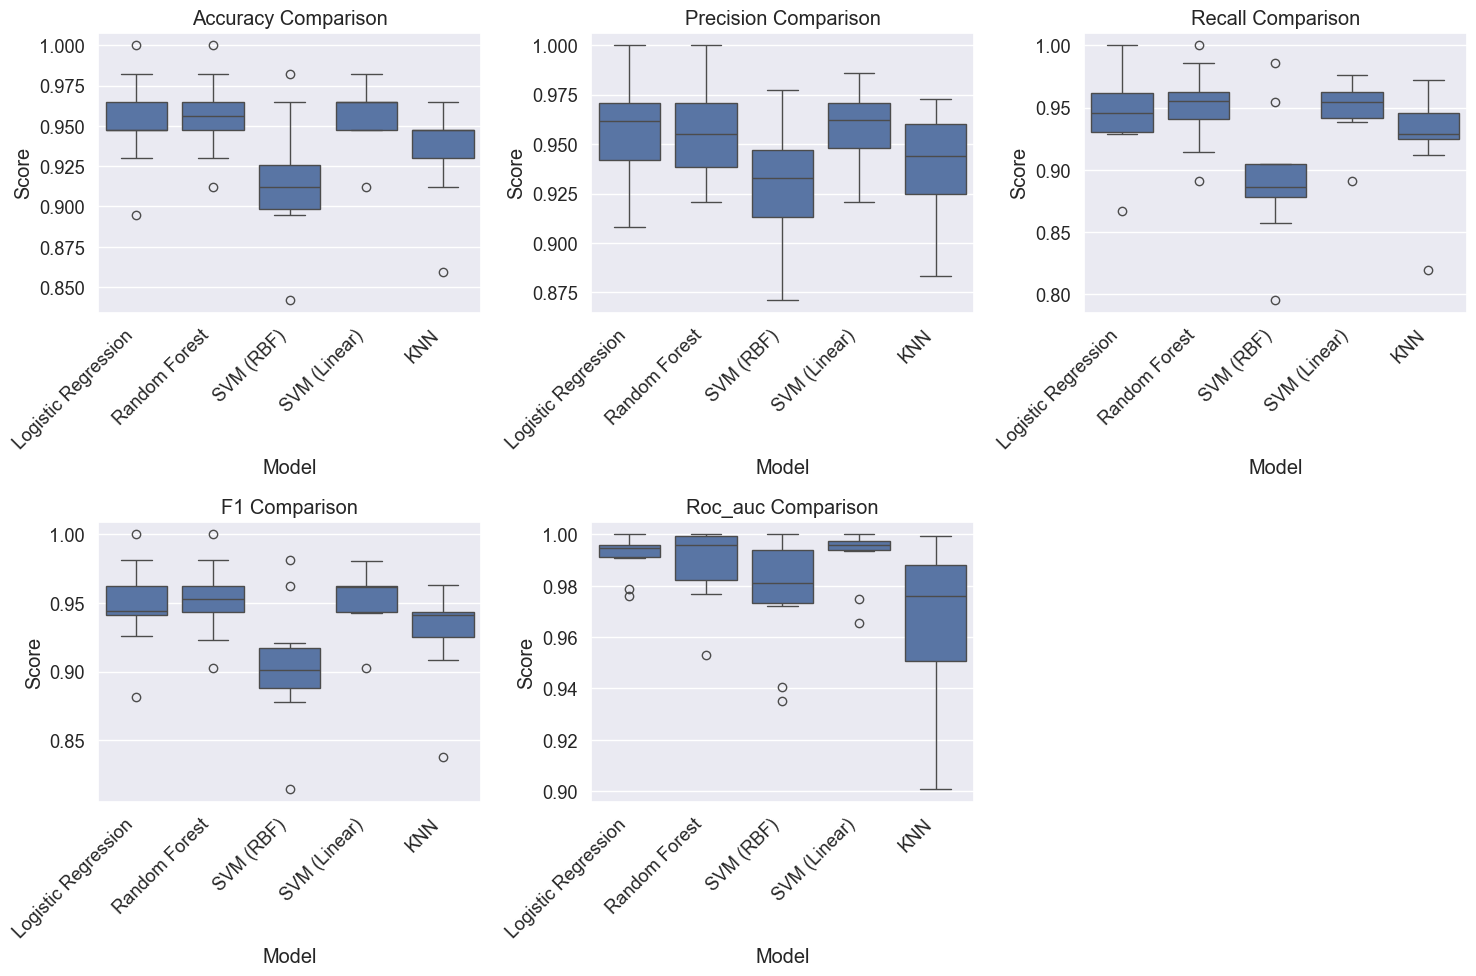


Statistical Significance Tests (p-values):

Metric: accuracy


,Logistic Regression,Random Forest,SVM (RBF),SVM (Linear),KNN
Logistic Regression,0.0000,0.5911,0.0269,0.5135,0.0519
Random Forest,0.5911,0.0000,0.0084,0.9965,0.0365
SVM (RBF),0.0269,0.0084,0.0000,0.0039,0.1017
SVM (Linear),0.5135,0.9965,0.0039,0.0000,0.0051
KNN,0.0519,0.0365,0.1017,0.0051,0.0000



Metric: precision


,Logistic Regression,Random Forest,SVM (RBF),SVM (Linear),KNN
Logistic Regression,0.0000,0.9351,0.0939,0.6576,0.0635
Random Forest,0.9351,0.0000,0.0461,0.8180,0.0731
SVM (RBF),0.0939,0.0461,0.0000,0.0211,0.4889
SVM (Linear),0.6576,0.8180,0.0211,0.0000,0.0113
KNN,0.0635,0.0731,0.4889,0.0113,0.0000



Metric: recall


,Logistic Regression,Random Forest,SVM (RBF),SVM (Linear),KNN
Logistic Regression,0.0000,0.4020,0.0094,0.5298,0.0492
Random Forest,0.4020,0.0000,0.0026,0.7665,0.0229
SVM (RBF),0.0094,0.0026,0.0000,0.0015,0.0261
SVM (Linear),0.5298,0.7665,0.0015,0.0000,0.0094
KNN,0.0492,0.0229,0.0261,0.0094,0.0000



Metric: f1


,Logistic Regression,Random Forest,SVM (RBF),SVM (Linear),KNN
Logistic Regression,0.0000,0.5576,0.0203,0.4827,0.0486
Random Forest,0.5576,0.0000,0.0070,0.9929,0.0344
SVM (RBF),0.0203,0.0070,0.0000,0.0033,0.0713
SVM (Linear),0.4827,0.9929,0.0033,0.0000,0.0063
KNN,0.0486,0.0344,0.0713,0.0063,0.0000



Metric: roc_auc


,Logistic Regression,Random Forest,SVM (RBF),SVM (Linear),KNN
Logistic Regression,0.0000,0.4939,0.0123,0.7743,0.0192
Random Forest,0.4939,0.0000,0.0258,0.5448,0.0044
SVM (RBF),0.0123,0.0258,0.0000,0.0060,0.1849
SVM (Linear),0.7743,0.5448,0.0060,0.0000,0.0168
KNN,0.0192,0.0044,0.1849,0.0168,0.0000


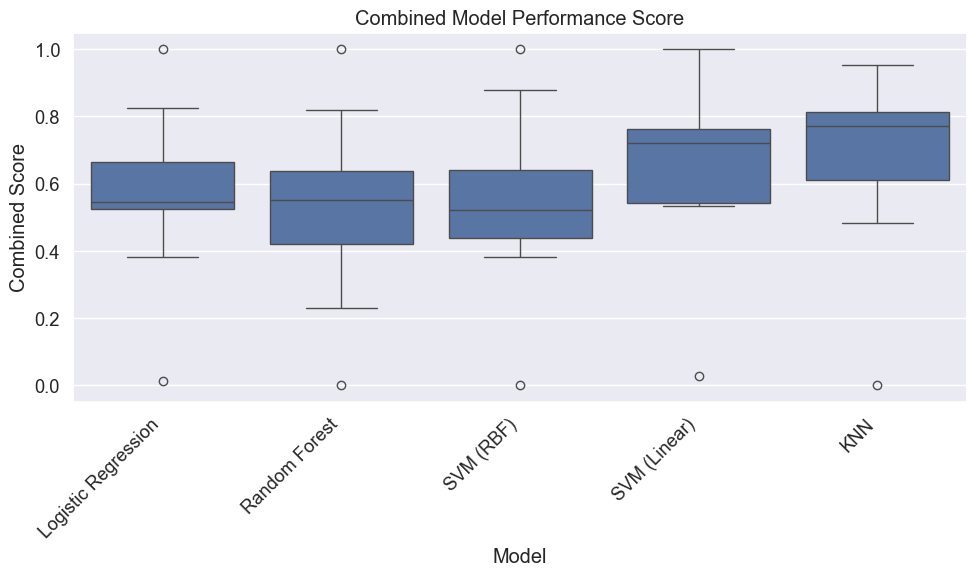


Final Model Recommendations:
Logistic Regression: Mean=0.5646, Std=0.2484
Random Forest: Mean=0.5284, Std=0.2706
SVM (RBF): Mean=0.5437, Std=0.2602
SVM (Linear): Mean=0.6409, Std=0.2451
KNN: Mean=0.6790, Std=0.2664


In [16]:
# Let's use the breast cancer dataset for this example
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

# Import joblib with a specific config to avoid the wmic error
import os
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())
import joblib

# Load the dataset
X, y = load_breast_cancer(return_X_y=True)

# Define several models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True),
    'SVM (Linear)': SVC(kernel='linear', probability=True),
    'KNN': KNeighborsClassifier()
}

# Set up cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Store results for each model
all_results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    # Set n_jobs=1 to avoid the wmic issue
    scores = cross_validate(
        model, X, y, cv=cv, n_jobs=1,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc'],
        return_train_score=True
    )
    
    all_results[name] = {
        'test_accuracy': scores['test_accuracy'],
        'test_precision': scores['test_precision_macro'],
        'test_recall': scores['test_recall_macro'],
        'test_f1': scores['test_f1_macro'],
        'test_roc_auc': scores['test_roc_auc'],
        'train_accuracy': scores['train_accuracy']
    }

# Create a comparison dataframe for test scores
comparison_data = []
for model_name, results in all_results.items():
    for metric_name, scores in results.items():
        if metric_name.startswith('test_'):
            for fold, score in enumerate(scores):
                comparison_data.append({
                    'Model': model_name,
                    'Metric': metric_name.replace('test_', ''),
                    'Fold': fold + 1,
                    'Score': score
                })

comparison_df = pd.DataFrame(comparison_data)

# Calculate summary statistics
summary = comparison_df.groupby(['Model', 'Metric'])['Score'].agg(['mean', 'std']).reset_index()
summary = summary.sort_values(by=['Metric', 'mean'], ascending=[True, False])

# Print summary table
print("\nModel Performance Summary:")
for metric in summary['Metric'].unique():
    print(f"\n{metric.upper()}")
    metric_data = summary[summary['Metric'] == metric].sort_values(by='mean', ascending=False)
    print(metric_data[['Model', 'mean', 'std']].to_string(index=False, 
                                                         float_format=lambda x: f"{x:.4f}"))

# Create visualizations for model comparison
plt.figure(figsize=(15, 10))

metrics = comparison_df['Metric'].unique()
for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    
    metric_data = comparison_df[comparison_df['Metric'] == metric]
    sns.boxplot(x='Model', y='Score', data=metric_data)
    
    plt.title(f'{metric.capitalize()} Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.tight_layout()
plt.show()

# Statistical significance testing (paired t-test)
print("\nStatistical Significance Tests (p-values):")
for metric in metrics:
    print(f"\nMetric: {metric}")
    
    # Create a table for p-values
    model_names = list(models.keys())
    p_values = np.zeros((len(model_names), len(model_names)))
    
    for i, model_1 in enumerate(model_names):
        for j, model_2 in enumerate(model_names):
            if i != j:
                # Get scores for both models
                scores_1 = all_results[model_1][f'test_{metric}']
                scores_2 = all_results[model_2][f'test_{metric}']
                
                # Perform paired t-test
                _, p_value = stats.ttest_rel(scores_1, scores_2)
                p_values[i, j] = p_value
    
    # Create a DataFrame for better visualization
    p_value_df = pd.DataFrame(p_values, index=model_names, columns=model_names)
    
    # Highlight significant differences (p < 0.05)
    def highlight_significant(val):
        color = 'yellow' if val < 0.05 else ''
        return f'background-color: {color}'
    
    # Display styled DataFrame
    styled_df = p_value_df.style.format("{:.4f}").applymap(highlight_significant)
    display(styled_df)

# Final model selection - calculate a combined score
# Normalize all metrics to 0-1 range and compute a weighted average
def normalize(scores):
    min_score = np.min(scores)
    max_score = np.max(scores)
    if max_score > min_score:
        return (scores - min_score) / (max_score - min_score)
    return np.zeros_like(scores)

# Define weights for each metric
weights = {
    'accuracy': 0.25,
    'precision': 0.25,
    'recall': 0.25,
    'f1': 0.15,
    'roc_auc': 0.1
}

# Calculate combined scores
combined_scores = {}

for model_name, results in all_results.items():
    combined = np.zeros(len(results['test_accuracy']))
    
    for metric, weight in weights.items():
        metric_scores = results[f'test_{metric}']
        # Get all scores across all models for this metric
        all_metric_scores = np.concatenate([res[f'test_{metric}'] for res in all_results.values()])
        # Normalize
        normalized = normalize(metric_scores)
        combined += weight * normalized
    
    combined_scores[model_name] = combined

# Create a DataFrame for combined scores
combined_df = pd.DataFrame({
    'Model': np.repeat(list(combined_scores.keys()), [len(scores) for scores in combined_scores.values()]),
    'Combined Score': np.concatenate(list(combined_scores.values()))
})

# Plot combined scores
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Combined Score', data=combined_df)
plt.title('Combined Model Performance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print final recommendations
print("\nFinal Model Recommendations:")
for model, scores in combined_scores.items():
    print(f"{model}: Mean={np.mean(scores):.4f}, Std={np.std(scores):.4f}")

## 10. Conclusion and Best Practices

In this notebook, we've explored various cross-validation techniques including:

1. **K-fold cross-validation**: The standard approach for model evaluation
2. **Stratified k-fold**: Preserves class distribution in imbalanced datasets
3. **Leave-one-out cross-validation**: Maximizes training data but is computationally expensive
4. **Time series cross-validation**: Respects temporal ordering in time series data
5. **Grid search with cross-validation**: For hyperparameter tuning
6. **Nested cross-validation**: For unbiased performance estimation

### Best Practices:

1. **Choose the right CV strategy** based on your data:
   - Use stratified k-fold for classification with imbalanced classes
   - Use time series CV for temporal data
   - Consider LOOCV for very small datasets

2. **Select appropriate k value**:
   - Common choices are k=5 or k=10
   - Larger k values reduce bias but increase variance and computational cost

3. **Always look at multiple metrics** rather than optimizing for a single one

4. **Visualize CV results** to understand model stability and performance distribution

5. **Use nested CV** when performing hyperparameter tuning to get unbiased performance estimates

6. **Remember that CV is just an estimate** of future performance - real-world conditions might differ

7. **Consider the computational cost** - more folds mean more training iterations

Cross-validation helps you build more robust models by providing a realistic assessment of their generalization abilities, which is fundamental to creating machine learning solutions that perform well in real-world applications.